In [24]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('archive/amz_uk_price_prediction_dataset.csv')


Generate a frequency table for the product category.

In [25]:
freq_tab = df['category'].value_counts()
freq_tab

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

Which are the top 5 most listed product categories?

In [19]:
freq_tab.head(5)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.

Text(0.5, 1.0, 'Top 10 Categories Amazon UK')

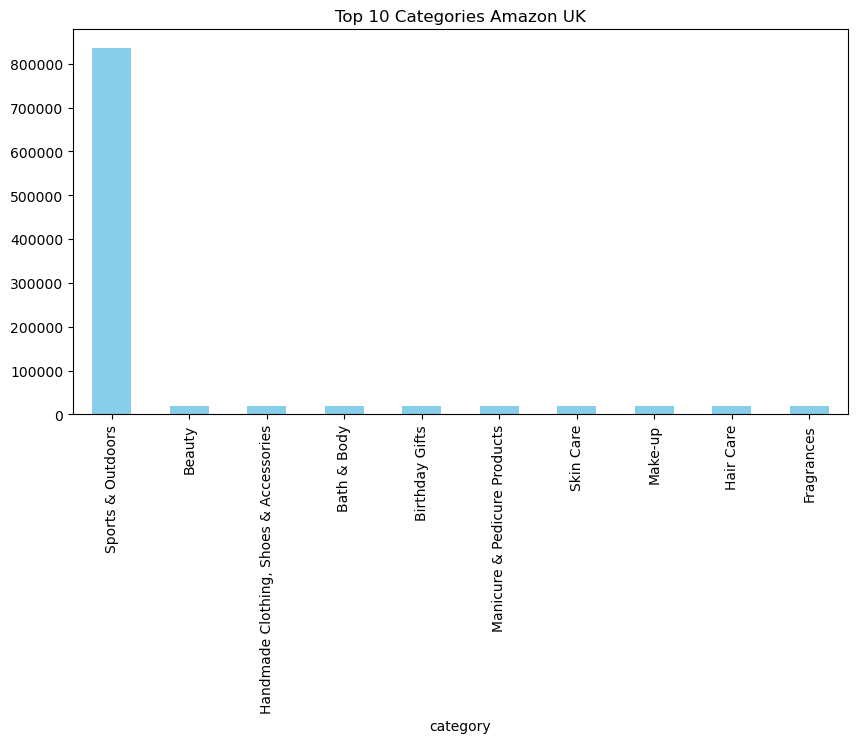

In [29]:
top_10 = freq_tab.head(10)
top_10.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Top 10 Categories Amazon UK')

For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

<Axes: ylabel='count'>

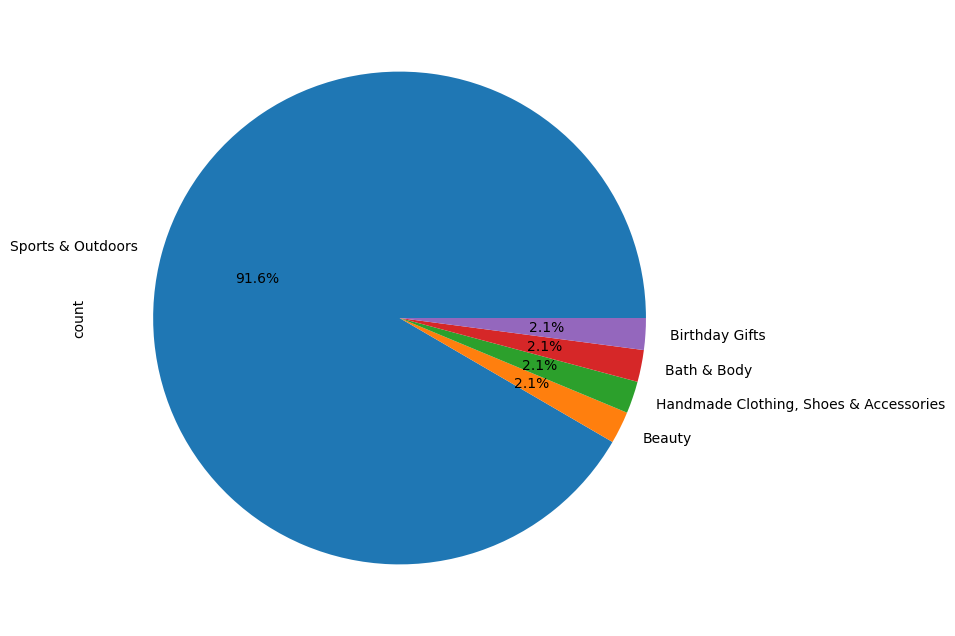

In [35]:
top_5 = freq_tab.head(5)
top_5.plot(kind='pie', figsize=(8, 8), autopct='%1.1f%%')

Measures of Centrality:

Calculate the mean, median, and mode for the price of products.

In [37]:
prod_mean = df['price'].mean()

In [39]:
prod_median = df['price'].median()

In [41]:
prod_mode = df['price'].mode()

In [50]:
print(f"Mean: {prod_mean}")
print(f"Median: {prod_median}")
print(f"Mode: {prod_mode}")

Mean: 89.24380943923661
Median: 19.09
Mode: 0    9.99
Name: price, dtype: float64


## What's the average price point of products listed? How does this compare with the most common price point (mode)?


In [80]:
print(f"Mean : {prod_mean:.2f}")
print(f"Mode : {prod_mode[0]}")

Mean : 89.24
Mode : 9.99


In [55]:
variance = df['price'].var()


In [66]:
std_dev = df['price'].std()

In [67]:
amplitude = df['price'].max() - df['price'].min()
amplitude

100000.0

In [76]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
iqr = Q3 - Q1

## Determine the variance, standard deviation, range, and interquartile range for product price. Are there indicators of a significant spread in product prices?

In [78]:
print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Range: {amplitude:.2f}")
print(f"IQR: {iqr:.2f}")

Variance: 119445.49
Standard Deviation: 345.61
Range: 100000.00
IQR: 36.00


yes there are indicatiors of a huge spread. the standard deviation from 345 is much higher

## Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices.

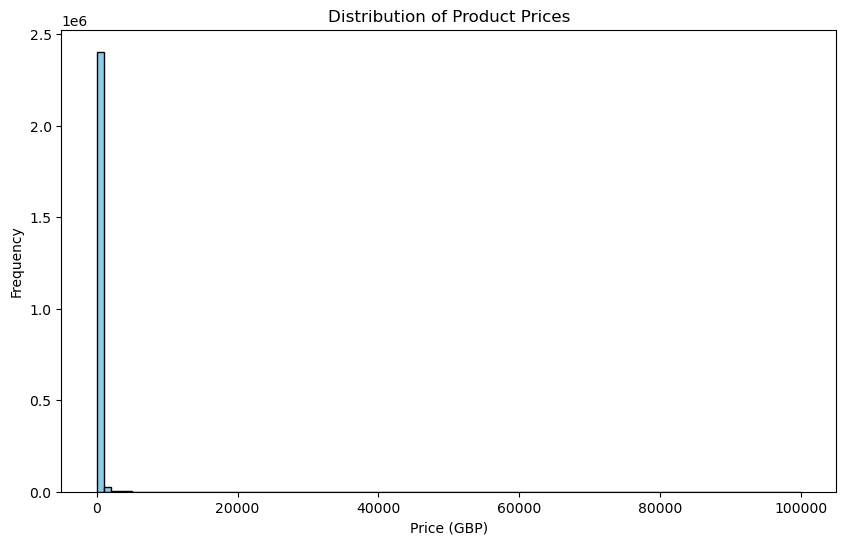

In [90]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=100, color='skyblue', edgecolor='black')
plt.title('Distribution of Product Prices')
plt.xlabel('Price (GBP)')
plt.ylabel('Frequency')
plt.show()

Since the price range goes from nearly 0 to 100,000 GBP the visualization "squashes" the majority of products into a single thin bar at the beginning of the scale

To solve this, we can apply data filtering (clipping). By limiting the view to a sub-section of the data

## Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.


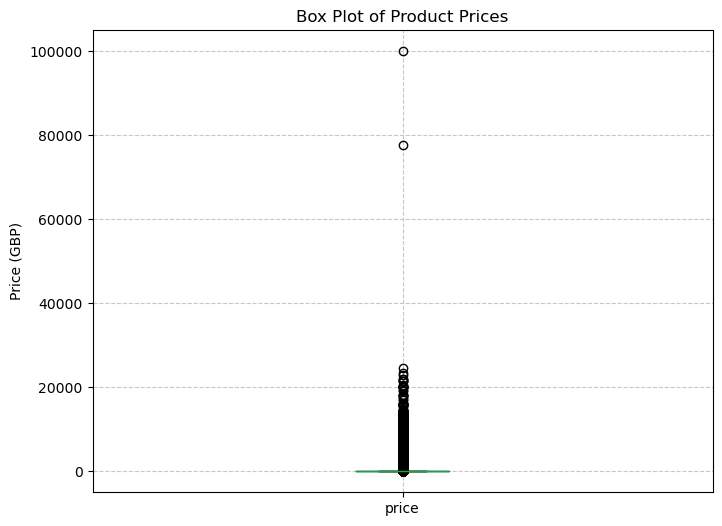

In [99]:
plt.figure(figsize=(8, 6))
df.boxplot(column='price')
plt.title('Box Plot of Product Prices')
plt.ylabel('Price (GBP)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## Calculate the mean, median, and mode for the rating of products

In [118]:
rating_mean = df['stars'].mean()
rating_median = df['stars'].median()
rating_mode = df['stars'].mode()[0]
print(f"Rating Mean: {rating_mean:.2f}")
print(f"Rating Median: {rating_median:.2f}")
print(f"Rating Mode: {rating_mode:.2f}")

Rating Mean: 2.15
Rating Median: 0.00
Rating Mode: 0.00


## How do customers generally rate products? Is there a common trend?

The most significant trend is that more than 50% of products carry a 0.0 rating

## Determine the variance, standard deviation, and interquartile range for product rating.

In [125]:
stars_variance = df['stars'].var()
stars_std = df['stars'].std()

q1 = df['stars'].quantile(0.25)
q3 = df['stars'].quantile(0.75)
stars_iqr = q3 - q1

In [127]:
print(f"Variance: {stars_variance:.2f}")
print(f"Standard Deviation: {stars_std:.2f}")
print(f"IQR: {stars_iqr:.2f}")

Variance: 4.82
Standard Deviation: 2.19
IQR: 4.40


## Are the ratings consistent, or is there a wide variation in customer feedback?

Because there are a lot of reviews with 0 it means that a lof ot products aren't reviewed, therefore the feedback varies

## Calculate the skewness and kurtosis for the rating column.

In [132]:
stars_skew = df['stars'].skew()
stars_kurt = df['stars'].kurtosis()

In [134]:
print(f"Skewness: {stars_skew:.2f}")
print(f"Kurtosis: {stars_kurt:.2f}")

Skewness: 0.08
Kurtosis: -1.93


## Are the ratings normally distributed, or do they lean towards higher or lower values?

they are in both extremes, almost nothing in the middle, meaning that customers usually dont do anything or if they do they give positive feedback

## Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

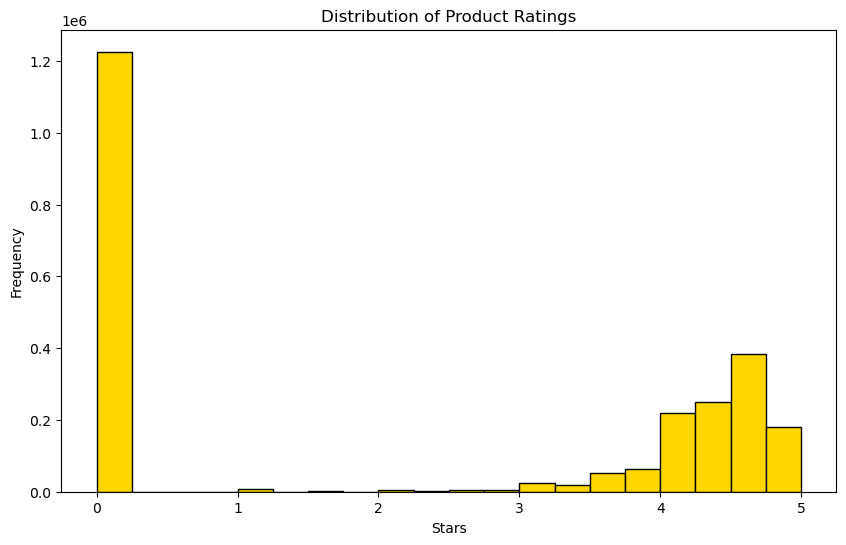

In [148]:
plt.figure(figsize=(10, 6))
plt.hist(df['stars'], bins=20, color='gold', edgecolor='black')
plt.title('Distribution of Product Ratings')
plt.xlabel('Stars')
plt.ylabel('Frequency')
plt.show()

Yes, 0.